Using device cpu
Epoch1/5 | Loss:0.3328
Epoch2/5 | Loss:0.2249
Epoch3/5 | Loss:0.3139
Epoch4/5 | Loss:0.3478
Epoch5/5 | Loss:0.5454
Total Accuarcy: 87.55%
Model saved as mnist_mdel.pth


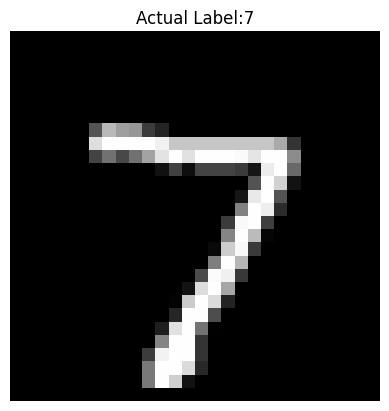

User picked image index 0
Actual Label 7
Model Prediction 0


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt




device="cuda" if torch.cuda.is_available() else "cpu"
print("Using device",device)

transform =transforms.ToTensor()

train_data=MNIST(
   root="data",
   train=True,
   download=True,
   transform=transform

)
test_data=MNIST(
     root="data",
   train=False,
   download=True,
   transform=transform

)

train_loader=DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader=DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),
             nn.Linear(128,64),
            nn.ReLU(),
             nn.Linear(64,10),
            nn.ReLU(),

        )

    def forward(self,x):
        return self.net(x)
    
model = DigitModel().to(device)

loss_fn=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

epochs=5
for epoch in range(epochs):
        model.train()
        total_loss=0

        for image,labels in train_loader:
            image=image.view(image.size(0),-1).to(device)
            labels=labels.to(device)
            optimizer.zero_grad()
            outputs=model(image)
            loss=loss_fn(outputs,labels)
            loss.backward()
            optimizer.step()
            total_loss=loss.item()
            
        print(f"Epoch{epoch+1}/{epochs} | Loss:{total_loss:.4f}")

model.eval()
correct=0
total=0

with torch.no_grad():
    for images,labels in test_loader:
        images=images.view(images.size(0),-1).to(device)
        labels=labels.to(device)
        
        outputs=model(images)
        predictions=outputs.argmax(dim=1)

        correct+=(predictions==labels).sum().item()
        total+=labels.size(0)

accuracy=100*correct/total
print(f"Total Accuarcy: {accuracy:.2f}%")

torch.save(model.state_dict(),"mnist_model.pth")
print("Model saved as mnist_mdel.pth")
index=0
image, true_label=test_data[index]

plt.imshow(image.squeeze(),cmap="gray")
plt.title(f"Actual Label:{true_label}")
plt.axis("off")
plt.show()

image_flat=image.view(1,-1).to(device)

with torch.no_grad():
    output=model(image_flat)
    predicted_label=output.argmax(dim=1).item()
    print("User picked image index",index)
    print("Actual Label",true_label)
    print("Model Prediction",predicted_label)
          




In [3]:
pip install torchvision


   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.3 MB 2.4 MB/s eta 0:00:02
   ------------ --------------------------- 1.3/4.3 MB 2.8 MB/s eta 0:00:02
   ------------------- -------------------- 2.1/4.3 MB 2.8 MB/s eta 0:00:01
   ------------------------ --------------- 2.6/4.3 MB 2.9 MB/s eta 0:00:01
   ------------------------------- -------- 3.4/4.3 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 3.1 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.
